# ABSA Training Pipeline
**Per Professor's Requirements**

- **Step 1**: Aspect Detection — Multi-label, 10 binary BCE losses
- **Step 2**: Sentiment Regression — output vector of 10 values in `[-1, 1]`, masked MSE
- **Step 3**: Calibration — threshold sweep, graph: X=Precision, Y=MSE
- **Step 4**: Evaluation — per-aspect Precision + MSE on test split
- **Step 5**: Inference — predict new reviews with calibrated thresholds


In [1]:
import os, json, random, time
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, f1_score, recall_score
from transformers import BertTokenizerFast, BertModel


@dataclass
class Config:
    MODEL_NAME:           str   = "bert-base-uncased"
    MAX_LEN:              int   = 160
    BATCH_SIZE:           int   = 16
    LR:                   float = 3e-5
    EPOCHS_DETECTION:     int   = 30
    EPOCHS_SENTIMENT:     int   = 30
    PATIENCE:             int   = 5

    SPLIT_CALIB:          float = 0.10
    SPLIT_TEST:           float = 0.10

    SENT2VAL: Dict[str, float] = field(default_factory=lambda: {
        "positive":  1.0,
        "negative": -1.0,
        "neutral":   0.0,
    })

    CHECKPOINT_DIR:  str  = "checkpoints_new"
    DET_CKPT:        str  = "detection_best.pt"
    SENT_CKPT:       str  = "sentiment_best.pt"
    THRESHOLDS_CKPT: str  = "thresholds.json"
    ASPECTS_CKPT:    str  = "aspects.json"
    FORCE_RETRAIN:   bool = False
    SEED:            int  = 42
    DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


CFG       = Config()
DATA_FILE = "o4_mini_final_student_reviews_clean.jsonl"

print(f"Device : {CFG.DEVICE}")
print(f"Data   : {DATA_FILE}")
print(f"Epochs : detection={CFG.EPOCHS_DETECTION}  sentiment={CFG.EPOCHS_SENTIMENT}")
print(f"LR     : {CFG.LR}   batch={CFG.BATCH_SIZE}   max_len={CFG.MAX_LEN}")


Device : cuda
Data   : o4_mini_final_student_reviews_clean.jsonl
Epochs : detection=30  sentiment=30
LR     : 3e-05   batch=16   max_len=160


In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(CFG.SEED)
print(f"Seed set to {CFG.SEED}")


Seed set to 42


## Data Loading & 3-Way Split

In [3]:
def load_jsonl(filepath: str) -> pd.DataFrame:
    rows, bad = [], 0
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line: continue
            try:
                obj = json.loads(line)
                rows.append({"text": obj.get("review_text", "").strip(),
                              "aspects": obj.get("aspects", {}) or {}})
            except json.JSONDecodeError:
                bad += 1
    df = pd.DataFrame(rows)
    if bad:  print(f"Warning: skipped {bad} invalid lines.")
    if not len(df): raise ValueError("No valid rows loaded.")
    return df


def discover_aspects(df: pd.DataFrame) -> List[str]:
    s = set()
    for d in df["aspects"]:
        if isinstance(d, dict): s.update(d.keys())
    return sorted(s)


def three_way_split(df, calib_size=0.10, test_size=0.10, seed=42):
    hold  = calib_size + test_size
    tr, ho = train_test_split(df, test_size=hold, random_state=seed)
    ca, te = train_test_split(ho, test_size=test_size/hold, random_state=seed)
    return tr.reset_index(drop=True), ca.reset_index(drop=True), te.reset_index(drop=True)


# ── run immediately ──
df      = load_jsonl(DATA_FILE)
aspects = discover_aspects(df)
train_df, calib_df, test_df = three_way_split(
    df, CFG.SPLIT_CALIB, CFG.SPLIT_TEST, CFG.SEED
)

print(f"Loaded {len(df)} reviews")
print(f"Aspects ({len(aspects)}): {aspects}")
print(f"\nSplit → train={len(train_df)} | calib={len(calib_df)} | test={len(test_df)}")


Loaded 5052 reviews
Aspects (10): ['clarity', 'difficulty', 'exam_fairness', 'interest', 'lecturer_quality', 'materials', 'overall_experience', 'relevance', 'support', 'workload']

Split → train=4041 | calib=505 | test=506


In [4]:
tokenizer = BertTokenizerFast.from_pretrained(CFG.MODEL_NAME)
print("Tokenizer ready:", CFG.MODEL_NAME)


Tokenizer ready: bert-base-uncased


## Models

In [5]:
class AspectDetectionHead(nn.Module):
    """BERT → 10 logits. Loss: BCEWithLogitsLoss. Inference: sigmoid → probs."""
    def __init__(self, model_name, num_aspects):
        super().__init__()
        self.bert       = BertModel.from_pretrained(model_name)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_aspects)
    def forward(self, input_ids, attention_mask):
        return self.classifier(self.bert(input_ids=input_ids,
                                          attention_mask=attention_mask).pooler_output)


class AspectSentimentHead(nn.Module):
    """BERT → 10 values in [-1,1].  Loss: masked MSE."""
    def __init__(self, model_name, num_aspects):
        super().__init__()
        self.bert      = BertModel.from_pretrained(model_name)
        self.regressor = nn.Linear(self.bert.config.hidden_size, num_aspects)
    def forward(self, input_ids, attention_mask):
        return torch.tanh(self.regressor(
            self.bert(input_ids=input_ids,
                      attention_mask=attention_mask).pooler_output
        ))


print("Models defined.")


Models defined.


## Datasets

In [6]:
class DetectionDataset(Dataset):
    def __init__(self, df, tokenizer, aspects, max_len):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.aspects = aspects
        self.a2i = {a: i for i, a in enumerate(aspects)}
        self.max_len = max_len
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        text = self.df.loc[idx, "text"]
        ad   = self.df.loc[idx, "aspects"]
        y = torch.zeros(len(self.aspects), dtype=torch.float)
        if isinstance(ad, dict):
            for a in ad:
                if a in self.a2i: y[self.a2i[a]] = 1.0
        enc = self.tokenizer(text, add_special_tokens=True, max_length=self.max_len,
                              truncation=True, padding="max_length", return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels": y}


class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, aspects, max_len, sent2val):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.aspects = aspects
        self.a2i = {a: i for i, a in enumerate(aspects)}
        self.max_len = max_len
        self.sent2val = sent2val
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        text = self.df.loc[idx, "text"]
        ad   = self.df.loc[idx, "aspects"]
        targets = torch.zeros(len(self.aspects), dtype=torch.float)
        mask    = torch.zeros(len(self.aspects), dtype=torch.float)
        if isinstance(ad, dict):
            for a, s in ad.items():
                if a in self.a2i and s in self.sent2val:
                    i = self.a2i[a]
                    targets[i] = self.sent2val[s]
                    mask[i]    = 1.0
        enc = self.tokenizer(text, add_special_tokens=True, max_length=self.max_len,
                              truncation=True, padding="max_length", return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "targets": targets, "mask": mask}


# ── sanity check ──
s0 = DetectionDataset(train_df.head(2), tokenizer, aspects, CFG.MAX_LEN)[0]
s1 = SentimentDataset(train_df.head(2), tokenizer, aspects, CFG.MAX_LEN, CFG.SENT2VAL)[0]
print("Detection  labels shape:", s0["labels"].shape)
print("Sentiment targets shape:", s1["targets"].shape)
print("Sentiment    mask shape:", s1["mask"].shape)
print("Mask values (first row):", s1["mask"].tolist())


Detection  labels shape: torch.Size([10])
Sentiment targets shape: torch.Size([10])
Sentiment    mask shape: torch.Size([10])
Mask values (first row): [0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0]


## Loss Functions & Evaluation Helpers

In [7]:
# ── Losses ──────────────────────────────────────────────────────────────────
def masked_mse_loss(preds, targets, mask):
    """MSE over labeled positions only. Normalised by # valid entries."""
    return ((preds - targets)**2 * mask).sum() / mask.sum().clamp(min=1.0)


def masked_mse_numpy(preds, targets, mask):
    n = mask.sum()
    if n == 0: return float("nan")
    return float(((preds - targets)**2 * mask).sum() / n)


# ── pos_weight for detection ─────────────────────────────────────────────────
def compute_pos_weight(train_df, tokenizer, aspects, max_len, device):
    ds  = DetectionDataset(train_df, tokenizer, aspects, max_len)
    ld  = DataLoader(ds, batch_size=64, shuffle=False)
    pos = np.zeros(len(aspects)); total = 0
    for b in ld:
        y = b["labels"].numpy(); pos += y.sum(0); total += y.shape[0]
    pw = np.clip((total - pos) / np.maximum(pos, 1.0), 1.0, 50.0)
    return torch.tensor(pw, dtype=torch.float, device=device)


# ── batch collectors ─────────────────────────────────────────────────────────
@torch.no_grad()
def collect_detection(model, loader, device=CFG.DEVICE):
    model.eval()
    P, Y = [], []
    for b in loader:
        logits = model(b["input_ids"].to(device), b["attention_mask"].to(device))
        P.append(torch.sigmoid(logits).cpu().numpy())
        Y.append(b["labels"].numpy())
    return np.vstack(P), np.vstack(Y)


@torch.no_grad()
def collect_sentiment(model, loader, device=CFG.DEVICE):
    model.eval()
    Pred, Tgt, Mask = [], [], []
    for b in loader:
        p = model(b["input_ids"].to(device), b["attention_mask"].to(device))
        Pred.append(p.cpu().numpy())
        Tgt.append(b["targets"].numpy())
        Mask.append(b["mask"].numpy())
    return np.vstack(Pred), np.vstack(Tgt), np.vstack(Mask)


# ── per-epoch detection metrics ──────────────────────────────────────────────
def detection_epoch_metrics(probs, true, threshold=0.5):
    """Returns micro/macro precision, recall, F1."""
    preds = (probs >= threshold).astype(int)
    return {
        "micro_prec":   float(precision_score(true.flatten(), preds.flatten(), zero_division=0)),
        "macro_prec":   float(precision_score(true, preds, average="macro",  zero_division=0)),
        "macro_recall": float(recall_score   (true, preds, average="macro",  zero_division=0)),
        "macro_f1":     float(f1_score        (true, preds, average="macro",  zero_division=0)),
        "micro_f1":     float(f1_score        (true.flatten(), preds.flatten(), average="micro", zero_division=0)),
    }


print("Loss functions and helpers ready.")


Loss functions and helpers ready.


## Step 1 — Train Aspect Detection Model

In [8]:
def train_detection(train_df, val_df, tokenizer, aspects, cfg):
    print("\n=== Step 1: Aspect Detection Training ===")
    os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
    ckpt = os.path.join(cfg.CHECKPOINT_DIR, cfg.DET_CKPT)

    model     = AspectDetectionHead(cfg.MODEL_NAME, len(aspects)).to(cfg.DEVICE)
    optimizer = AdamW(model.parameters(), lr=cfg.LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=2, verbose=False
    )
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=compute_pos_weight(train_df, tokenizer, aspects, cfg.MAX_LEN, cfg.DEVICE)
    )

    train_ld = DataLoader(DetectionDataset(train_df, tokenizer, aspects, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=True)
    val_ld   = DataLoader(DetectionDataset(val_df,   tokenizer, aspects, cfg.MAX_LEN),
                          batch_size=cfg.BATCH_SIZE, shuffle=False)

    n_batches    = len(train_ld)
    best_score   = -1.0
    patience_cnt = 0
    train_start  = time.time()

    for epoch in range(cfg.EPOCHS_DETECTION):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"\n{'─'*55}")
        print(f"  epoch          = {epoch+1} / {cfg.EPOCHS_DETECTION}")
        print(f"  learning_rate  = {current_lr:.2e}")
        print(f"{'─'*55}")

        # ── train loop with progress bar ──────────────────────
        model.train()
        total_loss  = 0.0
        epoch_start = time.time()

        for batch_idx, batch in enumerate(train_ld):
            optimizer.zero_grad()
            logits = model(batch["input_ids"].to(cfg.DEVICE),
                           batch["attention_mask"].to(cfg.DEVICE))
            loss = criterion(logits, batch["labels"].to(cfg.DEVICE))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            done    = batch_idx + 1
            elapsed = time.time() - epoch_start
            eta     = (elapsed / done) * (n_batches - done)
            filled  = int(30 * done / n_batches)
            bar     = "█" * filled + "░" * (30 - filled)
            print(f"\r  [{bar}] {done}/{n_batches}  "
                  f"elapsed={elapsed:.1f}s  eta={eta:.1f}s  "
                  f"batch_loss={total_loss/done:.4f}",
                  end="", flush=True)

        print()  # newline after progress bar
        epoch_time = time.time() - epoch_start

        # ── validation ────────────────────────────────────────
        avg_train_loss = total_loss / n_batches
        probs_v, true_v = collect_detection(model, val_ld, cfg.DEVICE)
        val_bce = float(
            F.binary_cross_entropy(
                torch.tensor(probs_v).clamp(1e-7, 1-1e-7),
                torch.tensor(true_v, dtype=torch.float)
            )
        )
        m = detection_epoch_metrics(probs_v, true_v)

        print(f"  train_loss     = {avg_train_loss:.4f}")
        print(f"  val_bce        = {val_bce:.4f}")
        print(f"  micro_prec     = {m['micro_prec']:.4f}")
        print(f"  macro_prec     = {m['macro_prec']:.4f}")
        print(f"  macro_recall   = {m['macro_recall']:.4f}")
        print(f"  macro_f1       = {m['macro_f1']:.4f}")
        print(f"  micro_f1       = {m['micro_f1']:.4f}")
        print(f"  epoch_time     = {epoch_time:.1f}s")
        print(f"  total_elapsed  = {time.time()-train_start:.1f}s")

        # ── scheduler + checkpoint ────────────────────────────
        score = m["macro_f1"]
        scheduler.step(score)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr < current_lr:
            print(f"  ⬇ lr_reduced   = {current_lr:.2e} → {new_lr:.2e}")

        if score > best_score + 1e-4:
            best_score, patience_cnt = score, 0
            torch.save(model.state_dict(), ckpt)
            print(f"  ✓ checkpoint   = saved  (best macro_f1={best_score:.4f})")
        else:
            patience_cnt += 1
            print(f"  patience       = {patience_cnt} / {cfg.PATIENCE}")
            if patience_cnt >= cfg.PATIENCE:
                print(f"  ✗ early_stop   = best macro_f1={best_score:.4f}")
                break

    model.load_state_dict(torch.load(ckpt, map_location=cfg.DEVICE, weights_only=True))
    print(f"\n  best model loaded")
    print(f"  total_train_time = {time.time()-train_start:.1f}s")
    return model


# ── run ──
if (not CFG.FORCE_RETRAIN) and os.path.exists(
        os.path.join(CFG.CHECKPOINT_DIR, CFG.DET_CKPT)):
    print("Detection checkpoint found — skipping training.")
    print("Set CFG.FORCE_RETRAIN = True to retrain.")
    det_model = AspectDetectionHead(CFG.MODEL_NAME, len(aspects)).to(CFG.DEVICE)
    det_model.load_state_dict(torch.load(
        os.path.join(CFG.CHECKPOINT_DIR, CFG.DET_CKPT),
        map_location=CFG.DEVICE, weights_only=True))
    det_model.eval()
else:
    det_model = train_detection(train_df, calib_df, tokenizer, aspects, CFG)



=== Step 1: Aspect Detection Training ===

───────────────────────────────────────────────────────
  epoch          = 1 / 30
  learning_rate  = 3.00e-05
───────────────────────────────────────────────────────
  [██████████████████████████████] 253/253  elapsed=42.4s  eta=0.0s  batch_loss=0.70752
  train_loss     = 0.7075
  val_bce        = 0.2575
  micro_prec     = 0.7649
  macro_prec     = 0.7850
  macro_recall   = 0.9490
  macro_f1       = 0.8557
  micro_f1       = 0.9396
  epoch_time     = 42.4s
  total_elapsed  = 44.0s
  ✓ checkpoint   = saved  (best macro_f1=0.8557)

───────────────────────────────────────────────────────
  epoch          = 2 / 30
  learning_rate  = 3.00e-05
───────────────────────────────────────────────────────
  [██████████████████████████████] 253/253  elapsed=42.8s  eta=0.0s  batch_loss=0.27346
  train_loss     = 0.2734
  val_bce        = 0.1509
  micro_prec     = 0.8648
  macro_prec     = 0.8718
  macro_recall   = 0.9566
  macro_f1       = 0.9101
  micro_f1

## Step 2 — Train Aspect Sentiment Regression Model

In [9]:
def train_sentiment(train_df, val_df, tokenizer, aspects, cfg):
    print("\n=== Step 2: Sentiment Regression Training ===")
    os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
    ckpt = os.path.join(cfg.CHECKPOINT_DIR, cfg.SENT_CKPT)

    model     = AspectSentimentHead(cfg.MODEL_NAME, len(aspects)).to(cfg.DEVICE)
    optimizer = AdamW(model.parameters(), lr=cfg.LR)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, verbose=False
    )

    train_ld = DataLoader(
        SentimentDataset(train_df, tokenizer, aspects, cfg.MAX_LEN, cfg.SENT2VAL),
        batch_size=cfg.BATCH_SIZE, shuffle=True)
    val_ld   = DataLoader(
        SentimentDataset(val_df, tokenizer, aspects, cfg.MAX_LEN, cfg.SENT2VAL),
        batch_size=cfg.BATCH_SIZE, shuffle=False)

    n_batches    = len(train_ld)
    best_loss    = float("inf")
    patience_cnt = 0
    train_start  = time.time()

    for epoch in range(cfg.EPOCHS_SENTIMENT):
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"\n{'─'*55}")
        print(f"  epoch          = {epoch+1} / {cfg.EPOCHS_SENTIMENT}")
        print(f"  learning_rate  = {current_lr:.2e}")
        print(f"{'─'*55}")

        # ── train loop with progress bar ──────────────────────
        model.train()
        total_loss  = 0.0
        epoch_start = time.time()

        for batch_idx, batch in enumerate(train_ld):
            optimizer.zero_grad()
            preds = model(batch["input_ids"].to(cfg.DEVICE),
                          batch["attention_mask"].to(cfg.DEVICE))
            loss = masked_mse_loss(preds,
                                   batch["targets"].to(cfg.DEVICE),
                                   batch["mask"].to(cfg.DEVICE))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            done    = batch_idx + 1
            elapsed = time.time() - epoch_start
            eta     = (elapsed / done) * (n_batches - done)
            filled  = int(30 * done / n_batches)
            bar     = "█" * filled + "░" * (30 - filled)
            print(f"\r  [{bar}] {done}/{n_batches}  "
                  f"elapsed={elapsed:.1f}s  eta={eta:.1f}s  "
                  f"batch_loss={total_loss/done:.4f}",
                  end="", flush=True)

        print()  # newline after progress bar
        epoch_time = time.time() - epoch_start

        # ── validation ────────────────────────────────────────
        avg_train = total_loss / n_batches
        preds_v, tgt_v, mask_v = collect_sentiment(model, val_ld, cfg.DEVICE)
        val_mse = masked_mse_numpy(preds_v, tgt_v, mask_v)

        print(f"  train_mse      = {avg_train:.4f}")
        print(f"  val_mse        = {val_mse:.4f}")
        print(f"  per_aspect_mse:")
        for ai, asp in enumerate(aspects):
            pa = masked_mse_numpy(preds_v[:, ai], tgt_v[:, ai], mask_v[:, ai])
            v  = f"{pa:.4f}" if not np.isnan(pa) else "  N/A"
            bar_v = "█" * int((1.0 - min(pa, 1.0)) * 10) if not np.isnan(pa) else ""
            print(f"    {asp:<22} = {v}  {bar_v}")
        print(f"  epoch_time     = {epoch_time:.1f}s")
        print(f"  total_elapsed  = {time.time()-train_start:.1f}s")

        # ── scheduler + checkpoint ────────────────────────────
        scheduler.step(val_mse)
        new_lr = optimizer.param_groups[0]["lr"]
        if new_lr < current_lr:
            print(f"  ⬇ lr_reduced   = {current_lr:.2e} → {new_lr:.2e}")

        if val_mse < best_loss - 1e-4:
            best_loss, patience_cnt = val_mse, 0
            torch.save(model.state_dict(), ckpt)
            print(f"  ✓ checkpoint   = saved  (best val_mse={best_loss:.4f})")
        else:
            patience_cnt += 1
            print(f"  patience       = {patience_cnt} / {cfg.PATIENCE}")
            if patience_cnt >= cfg.PATIENCE:
                print(f"  ✗ early_stop   = best val_mse={best_loss:.4f}")
                break

    model.load_state_dict(torch.load(ckpt, map_location=cfg.DEVICE, weights_only=True))
    print(f"\n  best model loaded")
    print(f"  total_train_time = {time.time()-train_start:.1f}s")
    return model


# ── run ──
if (not CFG.FORCE_RETRAIN) and os.path.exists(
        os.path.join(CFG.CHECKPOINT_DIR, CFG.SENT_CKPT)):
    print("Sentiment checkpoint found — skipping training.")
    sent_model = AspectSentimentHead(CFG.MODEL_NAME, len(aspects)).to(CFG.DEVICE)
    sent_model.load_state_dict(torch.load(
        os.path.join(CFG.CHECKPOINT_DIR, CFG.SENT_CKPT),
        map_location=CFG.DEVICE, weights_only=True))
    sent_model.eval()
else:
    sent_model = train_sentiment(train_df, calib_df, tokenizer, aspects, CFG)



=== Step 2: Sentiment Regression Training ===

───────────────────────────────────────────────────────
  epoch          = 1 / 30
  learning_rate  = 3.00e-05
───────────────────────────────────────────────────────
  [██████████████████████████████] 253/253  elapsed=42.5s  eta=0.0s  batch_loss=0.38469
  train_mse      = 0.3846
  val_mse        = 0.1601
  per_aspect_mse:
    clarity                = 0.1764  ████████
    difficulty             = 0.2156  ███████
    exam_fairness          = 0.1193  ████████
    interest               = 0.1139  ████████
    lecturer_quality       = 0.2041  ███████
    materials              = 0.1311  ████████
    overall_experience     = 0.0590  █████████
    relevance              = 0.1969  ████████
    support                = 0.1805  ████████
    workload               = 0.1438  ████████
  epoch_time     = 42.5s
  total_elapsed  = 44.2s
  ✓ checkpoint   = saved  (best val_mse=0.1601)

───────────────────────────────────────────────────────
  epoch       

## Step 3 — Calibration Graph

Each point on the curve = one global threshold θ.  
**X axis**: detection precision at θ  
**Y axis**: sentiment MSE on aspects that passed θ  
Colour = value of θ (dark=low, yellow=high).



=== Step 3: Calibration Graph ===


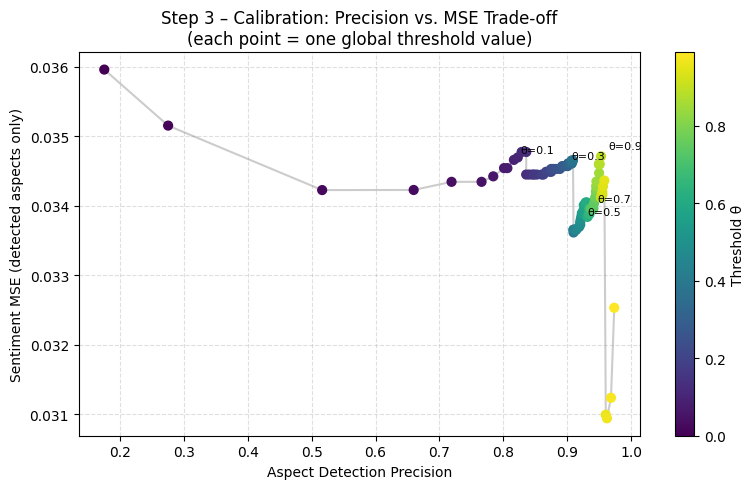

  Graph saved → calibration_graph.png

  Per-aspect best threshold (F1-optimal on calib):
    clarity               : threshold=0.75  (F1=0.9283)
    difficulty            : threshold=0.80  (F1=0.8922)
    exam_fairness         : threshold=0.95  (F1=1.0000)
    interest              : threshold=0.70  (F1=0.9268)
    lecturer_quality      : threshold=0.10  (F1=0.9398)
    materials             : threshold=0.65  (F1=0.9697)
    overall_experience    : threshold=0.30  (F1=0.9000)
    relevance             : threshold=0.30  (F1=0.9574)
    support               : threshold=0.85  (F1=0.9831)
    workload              : threshold=0.30  (F1=0.9796)

Checkpoints saved.


In [10]:
def calibration_graph(det_model, sent_model, calib_df,
                       tokenizer, aspects, cfg,
                       save_path="calibration_graph.png"):
    print("\n=== Step 3: Calibration Graph ===")

    det_ld  = DataLoader(DetectionDataset(calib_df, tokenizer, aspects, cfg.MAX_LEN),
                         batch_size=cfg.BATCH_SIZE, shuffle=False)
    sent_ld = DataLoader(SentimentDataset(calib_df, tokenizer, aspects,
                                          cfg.MAX_LEN, cfg.SENT2VAL),
                         batch_size=cfg.BATCH_SIZE, shuffle=False)

    det_probs, det_true = collect_detection(det_model, det_ld, cfg.DEVICE)
    sent_preds, sent_tgt, sent_mask = collect_sentiment(sent_model, sent_ld, cfg.DEVICE)

    thresholds   = np.linspace(0.0, 1.0, 101)
    curve_points = []
    for t in thresholds:
        pm  = (det_probs >= t).astype(float)
        n   = pm.sum()
        if n == 0:
            curve_points.append((float(t), 1.0, np.nan)); continue
        prec = float((pm * det_true).sum() / n)
        mse  = masked_mse_numpy(sent_preds, sent_tgt, pm * sent_mask)
        curve_points.append((float(t), prec, mse))

    df_curve = pd.DataFrame(curve_points, columns=["threshold","precision","mse"]).dropna()

    # ── plot ──
    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(df_curve["precision"], df_curve["mse"],
                    c=df_curve["threshold"], cmap="viridis", s=40, zorder=3)
    ax.plot(df_curve["precision"], df_curve["mse"], alpha=0.4, color="gray")
    cbar = plt.colorbar(sc, ax=ax); cbar.set_label("Threshold θ")
    for t_ann in [0.1, 0.3, 0.5, 0.7, 0.9]:
        row = df_curve[np.abs(df_curve["threshold"] - t_ann) < 0.015]
        if not row.empty:
            r = row.iloc[0]
            ax.annotate(f"θ={t_ann:.1f}", (r["precision"], r["mse"]),
                        textcoords="offset points", xytext=(5,5), fontsize=8)
    ax.set_xlabel("Aspect Detection Precision")
    ax.set_ylabel("Sentiment MSE (detected aspects only)")
    ax.set_title("Step 3 – Calibration: Precision vs. MSE Trade-off\n"
                 "(each point = one global threshold value)")
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.show()
    print(f"  Graph saved → {save_path}")

    # ── per-aspect best threshold ──
    best_thresholds = {}
    print("\n  Per-aspect best threshold (F1-optimal on calib):")
    for ai, aspect in enumerate(aspects):
        best_f1, best_t = -1.0, 0.5
        for t in np.linspace(0.05, 0.95, 19):
            f1a = f1_score(det_true[:, ai], (det_probs[:, ai] >= t).astype(int),
                           zero_division=0)
            if f1a > best_f1: best_f1, best_t = f1a, float(t)
        best_thresholds[aspect] = best_t
        print(f"    {aspect:22s}: threshold={best_t:.2f}  (F1={best_f1:.4f})")

    return df_curve, best_thresholds


def save_metadata(aspects, thresholds, cfg):
    os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)
    with open(os.path.join(cfg.CHECKPOINT_DIR, cfg.ASPECTS_CKPT), "w") as f:
        json.dump(aspects, f, indent=2)
    with open(os.path.join(cfg.CHECKPOINT_DIR, cfg.THRESHOLDS_CKPT), "w") as f:
        json.dump({a: float(v) for a, v in thresholds.items()}, f, indent=2)


def load_metadata(cfg):
    with open(os.path.join(cfg.CHECKPOINT_DIR, cfg.ASPECTS_CKPT)) as f:
        asp = json.load(f)
    with open(os.path.join(cfg.CHECKPOINT_DIR, cfg.THRESHOLDS_CKPT)) as f:
        thr = json.load(f)
    return asp, thr


# ── run ──
thr_path = os.path.join(CFG.CHECKPOINT_DIR, CFG.THRESHOLDS_CKPT)
if (not CFG.FORCE_RETRAIN) and os.path.exists(thr_path):
    print("Thresholds found — loading from checkpoint.")
    aspects, thresholds = load_metadata(CFG)
    print("  Loaded thresholds:", thresholds)
else:
    df_curve, thresholds = calibration_graph(
        det_model, sent_model, calib_df, tokenizer, aspects, CFG
    )
    save_metadata(aspects, thresholds, CFG)
    print("\nCheckpoints saved.")


## Step 4 — Evaluation on Test Split

In [11]:
def evaluate_on_test(det_model, sent_model, test_df,
                     tokenizer, aspects, thresholds, cfg):
    """
    Per-aspect metrics on the test split:
      - Accuracy  = (TP + TN) / N   (detection)
      - Precision = TP / (TP + FP)  (detection)
      - MSE       = masked MSE of sentiment regression
    """
    print("\n=== Step 4: Test Evaluation ===")
    thr_vec = np.array([thresholds[a] for a in aspects], dtype=np.float32)

    det_ld  = DataLoader(DetectionDataset(test_df, tokenizer, aspects, cfg.MAX_LEN),
                         batch_size=cfg.BATCH_SIZE, shuffle=False)
    sent_ld = DataLoader(SentimentDataset(test_df, tokenizer, aspects,
                                          cfg.MAX_LEN, cfg.SENT2VAL),
                         batch_size=cfg.BATCH_SIZE, shuffle=False)

    det_probs, det_true = collect_detection(det_model, det_ld, cfg.DEVICE)
    sent_preds, sent_tgt, sent_mask = collect_sentiment(sent_model, sent_ld, cfg.DEVICE)
    det_preds = (det_probs >= thr_vec).astype(int)

    N = len(test_df)
    rows = []
    for ai, aspect in enumerate(aspects):
        yt   = det_true[:, ai]   # ground truth binary
        yp   = det_preds[:, ai]  # predicted binary

        tp = int((yp * yt).sum())
        tn = int(((1-yp) * (1-yt)).sum())
        fp = int((yp * (1-yt)).sum())
        fn = int(((1-yp) * yt).sum())

        accuracy  = (tp + tn) / N
        precision = tp / (tp + fp) if (tp + fp) > 0 else float("nan")
        recall    = tp / (tp + fn) if (tp + fn) > 0 else float("nan")

        # MSE only where detection fired AND sentiment label exists
        eff_mask = yp * sent_mask[:, ai]
        mse = masked_mse_numpy(sent_preds[:, ai], sent_tgt[:, ai], eff_mask)

        rows.append({
            "aspect":     aspect,
            "accuracy":   accuracy,
            "precision":  precision,
            "recall":     recall,
            "mse":        mse,
            "threshold":  thresholds[aspect],
            "tp": tp, "tn": tn, "fp": fp, "fn": fn,
            "n_true":     int(yt.sum()),
        })

    df_res = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)

    # ── print table ──
    print(f"\n  {'Aspect':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>7} "
          f"{'MSE':>8} {'Thr':>5}  TP   TN   FP   FN")
    print("  " + "-" * 90)
    for _, r in df_res.iterrows():
        prec = f"{r['precision']:.4f}" if not np.isnan(r['precision']) else "   N/A"
        mse  = f"{r['mse']:.4f}"       if not np.isnan(r['mse'])       else "   N/A"
        print(f"  {r['aspect']:<22} {r['accuracy']:>9.4f} {prec:>10} "
              f"{r['recall']:>7.4f} {mse:>8} {r['threshold']:>5.2f} "
              f" {r['tp']:>3}  {r['tn']:>3}  {r['fp']:>3}  {r['fn']:>3}")

    return df_res


# ── run ──
results_df = evaluate_on_test(
    det_model, sent_model, test_df, tokenizer, aspects, thresholds, CFG
)
results_df.to_csv("test_results.csv", index=False)
print("\nSaved → test_results.csv")



=== Step 4: Test Evaluation ===

  Aspect                  Accuracy  Precision  Recall      MSE   Thr  TP   TN   FP   FN
  ------------------------------------------------------------------------------------------
  exam_fairness             1.0000     1.0000  1.0000   0.0166  0.95   85  421    0    0
  materials                 0.9921     0.9700  0.9898   0.0253  0.65   97  405    3    1
  support                   0.9881     0.9639  0.9639   0.0107  0.85   80  420    3    3
  workload                  0.9783     0.9200  0.9684   0.0478  0.30   92  403    8    3
  lecturer_quality          0.9723     0.8889  0.9143   0.0693  0.10   64  428    8    6
  clarity                   0.9644     0.9379  0.9379   0.0311  0.75  136  352    9    9
  interest                  0.9605     0.8636  0.9048   0.0207  0.70   76  410   12    8
  difficulty                0.9545     0.8652  0.8750   0.1239  0.80   77  406   12   11
  relevance                 0.9545     0.7857  0.9296   0.0501  0.30   66

In [12]:
display(results_df.style
    .format({
        "accuracy":  "{:.4f}",
        "precision": "{:.4f}",
        "recall":    "{:.4f}",
        "mse":       "{:.4f}",
        "threshold": "{:.2f}",
    })
    .background_gradient(subset=["accuracy"],  cmap="Blues")
    .background_gradient(subset=["precision"], cmap="Greens")
    .background_gradient(subset=["recall"],    cmap="Purples")
    .background_gradient(subset=["mse"],       cmap="Reds_r")
    .set_caption("Step 4 — Per-Aspect Results on Test Split (Accuracy + Precision + Recall + MSE)")
)


,aspect,accuracy,precision,recall,mse,threshold,tp,tn,fp,fn,n_true
0,exam_fairness,1.0000,1.0000,1.0000,0.0166,0.95,85,421,0,0,85
1,materials,0.9921,0.9700,0.9898,0.0253,0.65,97,405,3,1,98
2,support,0.9881,0.9639,0.9639,0.0107,0.85,80,420,3,3,83
3,workload,0.9783,0.9200,0.9684,0.0478,0.30,92,403,8,3,95
4,lecturer_quality,0.9723,0.8889,0.9143,0.0693,0.10,64,428,8,6,70
5,clarity,0.9644,0.9379,0.9379,0.0311,0.75,136,352,9,9,145
6,interest,0.9605,0.8636,0.9048,0.0207,0.70,76,410,12,8,84
7,difficulty,0.9545,0.8652,0.8750,0.1239,0.80,77,406,12,11,88
8,relevance,0.9545,0.7857,0.9296,0.0501,0.30,66,417,18,5,71
9,overall_experience,0.9368,0.7342,0.8406,0.0159,0.30,58,416,21,11,69


---
## Inference on New Reviews

In [13]:
# ── Load calibrated thresholds ──────────────────────────────────────────────
aspects_inf, thresholds_loaded = load_metadata(CFG)

print("Loaded thresholds:")
for a, t in thresholds_loaded.items():
    print(f"  {a:22s}: {t:.2f}")


Loaded thresholds:
  clarity               : 0.75
  difficulty            : 0.80
  exam_fairness         : 0.95
  interest              : 0.70
  lecturer_quality      : 0.10
  materials             : 0.65
  overall_experience    : 0.30
  relevance             : 0.30
  support               : 0.85
  workload              : 0.30


In [ ]:

#
manual_overrides = {
    # "overall_experience": 0.70,
    # "interest":           0.80,
    # "relevance":          0.50,
}

thresholds_final = {**thresholds_loaded, **manual_overrides}

print("Final thresholds:")
for a, t in thresholds_final.items():
    tag = "  ← OVERRIDDEN" if a in manual_overrides else ""
    print(f"  {a:22s}: {t:.2f}{tag}")


Final thresholds:
  clarity               : 0.75
  difficulty            : 0.80
  exam_fairness         : 0.95
  interest              : 0.70
  lecturer_quality      : 0.10
  materials             : 0.65
  overall_experience    : 0.30
  relevance             : 0.30
  support               : 0.85
  workload              : 0.30


In [15]:
def predict_review(text, det_model, sent_model, tokenizer,
                   aspects, thresholds, cfg, top_k=5):
    det_model.eval(); sent_model.eval()
    thr_vec = [thresholds[a] for a in aspects]

    enc = tokenizer(text, add_special_tokens=True, max_length=cfg.MAX_LEN,
                    truncation=True, padding="max_length",
                    return_tensors="pt").to(cfg.DEVICE)

    with torch.no_grad():
        det_probs   = torch.sigmoid(
            det_model(enc["input_ids"], enc["attention_mask"])
        ).squeeze(0).cpu().numpy()
        sent_scores = sent_model(
            enc["input_ids"], enc["attention_mask"]
        ).squeeze(0).cpu().numpy()

    def score_to_label(s):
        if s >  0.2: return "positive"
        if s < -0.2: return "negative"
        return "neutral"

    detected = [
        {"aspect": a,
         "sentiment_score": round(float(sent_scores[i]), 4),
         "sentiment_label": score_to_label(sent_scores[i]),
         "presence_prob":   round(float(det_probs[i]), 4),
         "threshold":       round(float(thr_vec[i]), 2)}
        for i, a in enumerate(aspects) if det_probs[i] >= thr_vec[i]
    ]
    detected.sort(key=lambda x: x["presence_prob"], reverse=True)

    top_k_debug = sorted(
        [{"aspect": aspects[i], "prob": round(float(det_probs[i]),4),
          "threshold": round(thr_vec[i],2),
          "triggered": bool(det_probs[i] >= thr_vec[i])}
         for i in range(len(aspects))],
        key=lambda x: x["prob"], reverse=True
    )[:top_k]

    return {"text": text, "detected": detected, "top_k_debug": top_k_debug}


def print_prediction(result):
    print(f"\n{'='*62}")
    print(f"  {result['text']}")
    print(f"{'='*62}")
    if not result["detected"]:
        print("  (no aspects detected)")
    else:
        print(f"  {'Aspect':<22} {'Label':<10} {'Score':>6}  {'Prob':>6}  {'Thr':>5}  Bar")
        print(f"  {'-'*60}")
        for a in result["detected"]:
            bar  = "█" * int(abs(a["sentiment_score"]) * 10)
            sign = "+" if a["sentiment_score"] > 0 else ""
            print(f"  {a['aspect']:<22} {a['sentiment_label']:<10} "
                  f"{sign}{a['sentiment_score']:>5.3f}  "
                  f"{a['presence_prob']:>6.3f}  "
                  f"{a['threshold']:>5.2f}  {bar}")
    print(f"  Top-{len(result['top_k_debug'])} all aspects:")
    for t in result["top_k_debug"]:
        flag = "✓" if t["triggered"] else "✗"
        print(f"    {flag} {t['aspect']:<22} prob={t['prob']:.3f}  thr={t['threshold']:.2f}")


print("Inference functions ready.")


Inference functions ready.


### Run on new reviews — edit `my_reviews` and re-run this cell

In [16]:
my_reviews = [
    "The lecturer was absolutely brilliant but the exams were way too hard.",
    "I learned nothing useful. The material is outdated and irrelevant to industry.",
    "Best course I've ever taken. Clear explanations, fair exams, and very supportive staff.",
    "The workload is insane but somehow I enjoyed every minute of it.",
    "Terrible experience. No feedback from TAs and the grading was random.",
    "The slides were well organized. The content was interesting but could be more challenging.",
    "Meh. It was fine.",
]

for text in my_reviews:
    result = predict_review(
        text, det_model, sent_model,
        tokenizer, aspects_inf, thresholds_final, CFG, top_k=5
    )
    print_prediction(result)



  The lecturer was absolutely brilliant but the exams were way too hard.
  Aspect                 Label       Score    Prob    Thr  Bar
  ------------------------------------------------------------
  lecturer_quality       positive   +0.986   0.997   0.10  █████████
  exam_fairness          negative   -0.928   0.952   0.95  █████████
  Top-5 all aspects:
    ✓ lecturer_quality       prob=0.997  thr=0.10
    ✓ exam_fairness          prob=0.952  thr=0.95
    ✗ difficulty             prob=0.474  thr=0.80
    ✗ clarity                prob=0.030  thr=0.75
    ✗ interest               prob=0.010  thr=0.70

  I learned nothing useful. The material is outdated and irrelevant to industry.
  Aspect                 Label       Score    Prob    Thr  Bar
  ------------------------------------------------------------
  relevance              negative   -0.978   0.999   0.30  █████████
  overall_experience     negative   -0.979   0.906   0.30  █████████
  Top-5 all aspects:
    ✓ relevance         

In [17]:
def batch_predict_df(reviews, det_model, sent_model,
                     tokenizer, aspects, thresholds, cfg):
    rows = []
    for i, text in enumerate(reviews):
        res = predict_review(text, det_model, sent_model,
                             tokenizer, aspects, thresholds, cfg)
        for a in res["detected"]:
            rows.append({
                "review_id":       i,
                "text":            text[:80] + ("..." if len(text)>80 else ""),
                "aspect":          a["aspect"],
                "sentiment_label": a["sentiment_label"],
                "sentiment_score": a["sentiment_score"],
                "presence_prob":   a["presence_prob"],
                "threshold":       a["threshold"],
            })
    return pd.DataFrame(rows)


df_pred = batch_predict_df(
    my_reviews, det_model, sent_model,
    tokenizer, aspects_inf, thresholds_final, CFG
)

display(df_pred.style
    .format({"sentiment_score": "{:+.3f}", "presence_prob": "{:.3f}", "threshold": "{:.2f}"})
    .applymap(lambda v:
        "background-color:#d4edda" if v=="positive" else
        "background-color:#f8d7da" if v=="negative" else
        "background-color:#fff3cd",
        subset=["sentiment_label"])
    .set_caption("ABSA Predictions — New Reviews")
)

df_pred.to_csv("new_reviews_predictions.csv", index=False)
print("Saved → new_reviews_predictions.csv")


C:\Users\guyy6\AppData\Local\Temp\ipykernel_47072\3817333676.py:25: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(df_pred.style


,review_id,text,aspect,sentiment_label,sentiment_score,presence_prob,threshold
0,0,The lecturer was absolutely brilliant but the exams were way too hard.,lecturer_quality,positive,+0.986,0.997,0.10
1,0,The lecturer was absolutely brilliant but the exams were way too hard.,exam_fairness,negative,-0.928,0.952,0.95
2,1,I learned nothing useful. The material is outdated and irrelevant to industry.,relevance,negative,-0.978,0.999,0.30
3,1,I learned nothing useful. The material is outdated and irrelevant to industry.,overall_experience,negative,-0.979,0.906,0.30
4,2,"Best course I've ever taken. Clear explanations, fair exams, and very supportive...",support,positive,+0.981,0.996,0.85
5,2,"Best course I've ever taken. Clear explanations, fair exams, and very supportive...",overall_experience,positive,+0.992,0.927,0.30
6,3,The workload is insane but somehow I enjoyed every minute of it.,workload,negative,-0.918,1.000,0.30
7,3,The workload is insane but somehow I enjoyed every minute of it.,interest,positive,+0.966,0.866,0.70
8,3,The workload is insane but somehow I enjoyed every minute of it.,overall_experience,positive,+0.976,0.822,0.30
9,4,Terrible experience. No feedback from TAs and the grading was random.,support,negative,-0.995,0.996,0.85


Saved → new_reviews_predictions.csv
